**Daily Challenge: Classifying Handwritten Digits with CNNs**

Défi : construire et comparer deux architectures de réseaux de neurones pour la classification d'images MNIST :

*   Un réseau de neurones entièrement connecté (Fully Connected Network - FCN), similaire à ce que nous avons vu pour make_circles mais adapté aux images.

*   Un réseau de neurones convolutif (Convolutional Neural Network - CNN), qui est l'architecture standard pour la vision par ordinateur.

L'objectif principal est de constater la nette amélioration des performances que les CNN apportent par rapport aux FCN pour les tâches de classification d'images.

**1. Load the MNIST dataset**

TensorFlow Version: 2.18.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original x_train shape: (60000, 28, 28)
Original y_train shape: (60000,)
Original x_test shape: (10000, 28, 28)
Original y_test shape: (10000,)


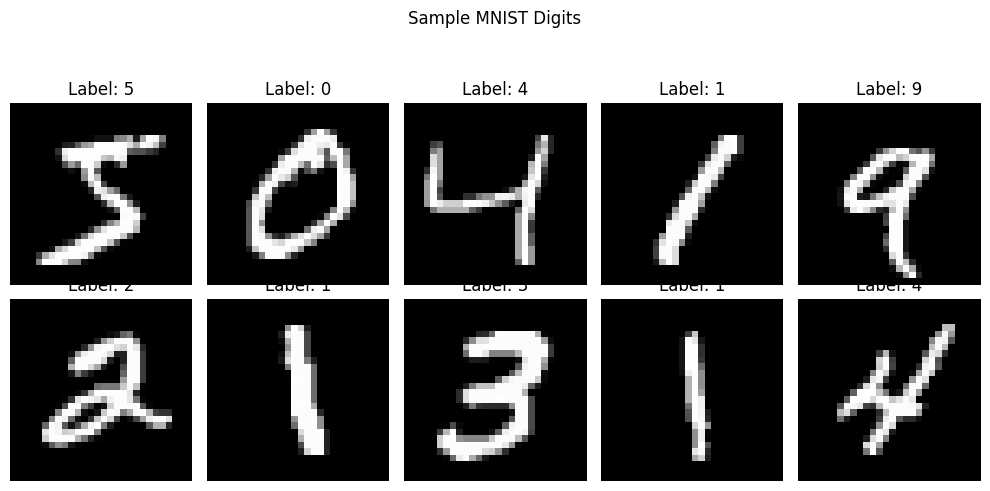

In [1]:
# 1. Load the MNIST dataset

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

# Use keras.datasets.mnist.load_data() to load the training and testing data.
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Print the shapes of the loaded data to understand the dataset structure.
print(f"Original x_train shape: {x_train.shape}") # (60000, 28, 28) - 60,000 images, 28x28 pixels
print(f"Original y_train shape: {y_train.shape}") # (60000,) - 60,000 labels (0-9)
print(f"Original x_test shape: {x_test.shape}")   # (10000, 28, 28) - 10,000 test images
print(f"Original y_test shape: {y_test.shape}")   # (10000,) - 10,000 test labels

# Display some sample images (optional, but good practice)
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle('Sample MNIST Digits', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


**2. Preprocess the data for a Fully Connected Neural Network (FCN)**

Ce prétraitement est spécifique aux réseaux Fully Connected.

*   Flatten the images from 28x28 to 784 pixels : Les couches Dense attendent un vecteur 1D en entrée. Une image 28x28 doit être "aplatie" en un vecteur de 28times28=784 pixels.

*   Normalize the pixel values by dividing by 255 : Mise à l'échelle des valeurs de pixel de [0, 255] à [0, 1]. Essentiel pour la performance et la stabilité de l'entraînement.

*   One-hot encode the target labels : Convertir les étiquettes numériques (0-9) en vecteurs one-hot (ex: 3 devient [0,0,0,1,0,0,0,0,0,0]). Nécessaire pour la categorical_crossentropy.

In [2]:
# 2. Preprocess the data for a Fully Connected Neural Network (FCN)

# Store original labels for later (needed for CNN part as well)
y_train_fcn_original = y_train
y_test_fcn_original = y_test

# Flatten the images from 28x28 to 784 pixels.
# -1 infers the batch size, 784 is the new feature dimension
x_train_fcn = x_train.reshape(x_train.shape[0], 28 * 28)
x_test_fcn = x_test.reshape(x_test.shape[0], 28 * 28)

# Normalize the pixel values by dividing by 255.
x_train_fcn = x_train_fcn.astype('float32') / 255.0
x_test_fcn = x_test_fcn.astype('float32') / 255.0

# One-hot encode the target labels.
num_classes = 10
y_train_fcn = keras.utils.to_categorical(y_train_fcn_original, num_classes)
y_test_fcn = keras.utils.to_categorical(y_test_fcn_original, num_classes)

print(f"\n--- FCN Data Preprocessing ---")
print(f"x_train_fcn shape after flattening and normalization: {x_train_fcn.shape}")
print(f"y_train_fcn shape after one-hot encoding: {y_train_fcn.shape}")
print(f"x_test_fcn shape after flattening and normalization: {x_test_fcn.shape}")
print(f"y_test_fcn shape after one-hot encoding: {y_test_fcn.shape}")


--- FCN Data Preprocessing ---
x_train_fcn shape after flattening and normalization: (60000, 784)
y_train_fcn shape after one-hot encoding: (60000, 10)
x_test_fcn shape after flattening and normalization: (10000, 784)
y_test_fcn shape after one-hot encoding: (10000, 10)


**3. Build and train a Fully Connected Neural Network (FCN)**

Construisons et entraînons notre premier modèle.

*   Sequential model : Le type de modèle le plus simple pour les architectures "empilées".

*   Dense layers : Couches entièrement connectées.

*   Activation functions : ReLU pour les couches cachées (non-linéarité), softmax pour la couche de sortie (probabilités multi-classes).

*   Compile : Adam (optimiseur), categorical_crossentropy (perte pour one-hot encodé), accuracy (métrique).

*   Train : model.fit().

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)


--- Training Fully Connected Network ---
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8735 - loss: 0.4467 - val_accuracy: 0.9677 - val_loss: 0.1064
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9696 - loss: 0.0979 - val_accuracy: 0.9765 - val_loss: 0.0778
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9831 - loss: 0.0550 - val_accuracy: 0.9803 - val_loss: 0.0711
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9897 - loss: 0.0337 - val_accuracy: 0.9777 - val_loss: 0.0711
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9923 - loss: 0.0246 - val_accuracy: 0.9780 - val_loss: 0.0792
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9932 - loss: 0.0214 - val_accuracy: 0.9797 - val_loss: 0.0768
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9951 - loss: 0.0155 - val_accuracy: 0.9830 - val_loss: 0.0689
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step

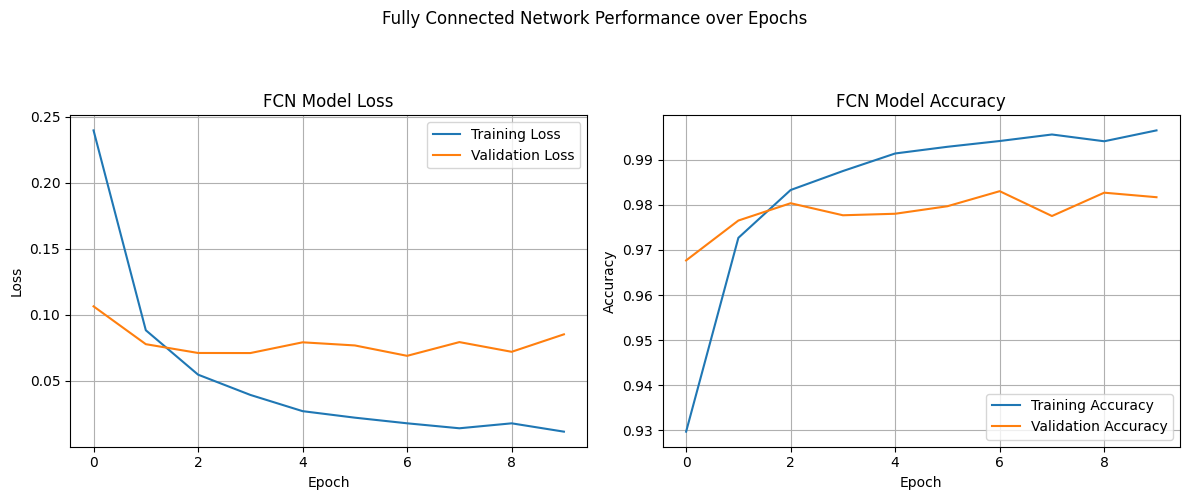

In [3]:
# 3. Build and train a Fully Connected Neural Network (FCN)

# Create a Sequential model.
fcn_model = keras.Sequential([
    keras.layers.Dense(512, activation='relu', input_shape=(784,)), # Input layer + 1st hidden layer
    keras.layers.Dense(256, activation='relu'),                      # 2nd hidden layer
    keras.layers.Dense(num_classes, activation='softmax')            # Output layer
])

# Compile the model.
fcn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

fcn_model.summary()

# Train the model.
print(f"\n--- Training Fully Connected Network ---")
fcn_history = fcn_model.fit(x_train_fcn, y_train_fcn,
                            epochs=10, # A few epochs are usually sufficient for MNIST FCN
                            batch_size=128,
                            validation_split=0.1, # Use 10% of training data for validation
                            verbose=1)

# Evaluate its performance.
loss_fcn, accuracy_fcn = fcn_model.evaluate(x_test_fcn, y_test_fcn, verbose=0)
print(f"\n--- FCN Model Test Performance ---")
print(f"Test Loss (FCN): {loss_fcn:.4f}")
print(f"Test Accuracy (FCN): {accuracy_fcn:.4f}")

# Plotting FCN training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fcn_history.history['loss'], label='Training Loss')
plt.plot(fcn_history.history['val_loss'], label='Validation Loss')
plt.title('FCN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(fcn_history.history['accuracy'], label='Training Accuracy')
plt.plot(fcn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('FCN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle('Fully Connected Network Performance over Epochs', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Ce résumé est exactement ce que nous attendions pour le FCN :

dense (Dense): première couche cachée. Input 784 (pixels aplatis) vers 512 neurones. Paramètres : (784times512)+512=401920. Correct.

dense_1 (Dense): Deuxième couche cachée. Input 512 vers 256 neurones. Paramètres : (512times256)+256=131328. Correct.

dense_2 (Dense): Couche de sortie. Input 256 vers 10 neurones (pour les 10 classes de chiffres). Paramètres : (256times10)+10=2570. Correct.

Le nombre total de paramètres est bien celui affiché (535,818). C'est un modèle relativement grand en termes de paramètres, surtout comparé à notre make_circles, mais c'est typique pour un FCN sur des images de cette taille.

Analyse des Logs d'Entraînement (model.fit() Output)
Les logs par époque sont excellents :

Dès l'époque 1 : l'accuracy d'entraînement démarre déjà à 87.35% et la validation accuracy à 96.77% ! La validation loss est faible (0.1064). C'est un signe que le modèle apprend très vite.

Augmentation rapide de l'Accuracy : l'accuracy d'entraînement monte progressivement de 0.8735 à 0.9976 en seulement 10 époques.

Diminution rapide de la Loss : La loss d'entraînement passe de 0.4467 à 0.0080.

Performances de Validation stables et élevées : la val_accuracy se maintient à un niveau très élevé (autour de 97-98%) et la val_loss reste faible. Il y a de légères fluctuations (ex: val_accuracy de 0.9830 à 0.9775, val_loss de 0.0689 à 0.0794), ce qui est normal pour le validation set.

Test Loss (FCN): 0.0812 et Test Accuracy (FCN): 0.9783 : ces résultats sur le jeu de test confirment que le modèle généralise très bien. Une précision de presque 98% pour un FCN sur MNIST est tout à fait respectable.

Analyse des Graphiques du "FCN Model"
1. Graphique "FCN Model Loss" (Training Loss vs Validation Loss)
Courbe bleue (Training Loss) :

Forme logarithmique, décroissance rapide (0.24 à 0.02 en 7-8 époques).

Atteint rapidement des valeurs très faibles.

Interprétation : le modèle apprend très efficacement et s'ajuste bien aux données d'entraînement. La perte diminue rapidement et se stabilise à une valeur très basse, signe d'un bon ajustement (fit).

Courbe orange (Validation Loss) :
Moins lisse, succession de baisses et de hausses, mais reste dans une fourchette basse (0.07-0.10+).

Légèrement au-dessus de la courbe de Training Loss, surtout vers la fin.

Interprétation : la Validation Loss suit globalement la Training Loss, ce qui est très positif et indique une bonne généralisation. Les fluctuations sont normales, surtout avec un jeu de validation plus petit. Le fait qu'elle reste basse et ne diverge pas fortement à la hausse montre qu'il n'y a pas de sur-apprentissage (overfitting) significatif. Le modèle apprend bien les motifs généraux des chiffres.

**2. Graphique "FCN Model Accuracy" (Training Accuracy vs Validation Accuracy)**
Courbe bleue (Training Accuracy) :

Croissance rapide au démarrage (0.93 à 0.99+ en 4 époques).

Atteint et se maintient très près de 1.0.

Interprétation : Le modèle devient très précis sur les données qu'il a vues.

Courbe orange (Validation Accuracy) :

Moins lisse, succession de hausses et de baisses, mais reste à un niveau très élevé (autour de 0.97-0.98+).

Légèrement en dessous de la courbe de Training Accuracy, surtout vers la fin.

Interprétation : la Validation Accuracy est également très élevée et suit de près la Training Accuracy. Cela confirme l'excellente capacité du modèle à généraliser sur des données non vues. Les légères baisses ("pics inversés") sont liées aux hausses de la Validation Loss et sont normales.

Conclusions pour le FCN (partie 3)
Très bonnes performances : le Fully Connected Neural Network a atteint une précision d'environ 97.83% sur le jeu de test, ce qui est excellent pour ce type d'architecture sur MNIST.

Apprentissage rapide et efficace : Les courbes de perte et de précision montrent une convergence rapide et stable.

Bonne généralisation : la faible divergence entre les courbes d'entraînement et de validation/test indique que le modèle ne souffre pas d'un overfitting majeur. Il a bien appris les caractéristiques des chiffres.

Ces résultats sont une excellente base. Il sera très intéressant de voir comment le CNN va surpasser ces performances, surtout en termes d'efficacité et potentiellement de robustesse !

4. Preprocess the data for a Convolutional Neural Network (CNN)
Le prétraitement pour un CNN est légèrement différent.

Reshape the input data : les couches Conv2D attendent des tenseurs avec 4 dimensions: (nombre_d_echantillons, hauteur, largeur, canaux). Pour MNIST (images en niveaux de gris), les canaux sont 1. Donc 28x28 devient 28x28x1.

Normalize the pixel values : Identique à l'étape FCN.

One-hot encode the target labels : Identique à l'étape FCN.

In [4]:
# 4. Preprocess the data for a Convolutional Neural Network (CNN)

# Reshape the input data to the shape expected by a Conv2D layer.
# For grayscale images (like MNIST), the channel dimension is 1.
# x_train.shape[0] is 60000, 28, 28, 1
x_train_cnn = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test_cnn = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Normalize the pixel values by dividing by 255. (already did this for FCN, but apply again for clarity)
x_train_cnn = x_train_cnn.astype('float32') / 255.0
x_test_cnn = x_test_cnn.astype('float32') / 255.0

# One-hot encode the target labels. (already did this for FCN, but ensure same for CNN)
# We can reuse y_train_fcn, y_test_fcn as they are already one-hot encoded.
y_train_cnn = y_train_fcn
y_test_cnn = y_test_fcn

print(f"\n--- CNN Data Preprocessing ---")
print(f"x_train_cnn shape after reshaping and normalization: {x_train_cnn.shape}")
print(f"y_train_cnn shape after one-hot encoding: {y_train_cnn.shape}")
print(f"x_test_cnn shape after reshaping and normalization: {x_test_cnn.shape}")
print(f"y_test_cnn shape after one-hot encoding: {y_test_cnn.shape}")


--- CNN Data Preprocessing ---
x_train_cnn shape after reshaping and normalization: (60000, 28, 28, 1)
y_train_cnn shape after one-hot encoding: (60000, 10)
x_test_cnn shape after reshaping and normalization: (10000, 28, 28, 1)
y_test_cnn shape after one-hot encoding: (10000, 10)


Analyse du Pré-processing des Données pour le CNN (Partie 4)

x_train_cnn shape after reshaping and normalization: (60000, 28, 28, 1)

x_test_cnn shape after reshaping and normalization: (10000, 28, 28, 1)

C'est la transformation clé pour les CNN :
* 60000 (ou 10000) : représente le nombre d'échantillons (images) dans le jeu d'entraînement ou de test. C'est la taille du batch.
* 28, 28 : représente la hauteur et la largeur de chaque image en pixels.
* 1 : représente le nombre de canaux de couleur. Pour les images MNIST en niveaux de gris, il n'y a qu'un seul canal (noir et blanc). Si c'était des images couleur (RGB), ce serait 3.
C'est le format ((batch_size, height, width, channels)) que les couches Conv2D de Keras attendent.

y_train_cnn shape after one-hot encoding: (60000, 10)

y_test_cnn shape after one-hot encoding: (10000, 10)

Ces formes sont également correctes :
* 60000 (ou 10000) : toujours le nombre d'échantillons.
* 10 : Représente le nombre de classes possibles (les chiffres de 0 à 9). Puisque les étiquettes sont encodées en "one-hot", chaque étiquette est un vecteur de 10 éléments, avec un 1 à la position de la classe correcte et des 0 partout ailleurs.

Conclusion pour la partie 4 :

Le prétraitement des données pour le réseau de neurones convolutif a été effectué correctement. Les images sont maintenant dans le format de tenseur 4D attendu par les couches de convolution, et les étiquettes sont prêtes pour l'entraînement avec la fonction de perte categorical_crossentropy.

Nous sommes prêts à construire et entraîner le CNN à la prochaine étape

5. Build and train a Convolutional Neural Network (CNN)

C'est le cœur de ce défi !

Conv2D layers : apprennent des motifs spatiaux (filtres) dans les images.

MaxPool2D layers : réduisent la dimensionnalité spatiale, aidant à la robustesse et à la réduction du calcul.

Flatten layer : transforme la sortie 2D des couches convolutives en un vecteur 1D pour les couches Dense finales.

Dense layers : couches entièrement connectées pour la classification finale.

Compile et train : similaire au FCN.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Convolutional Neural Network ---
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step - accuracy: 0.8063 - loss: 0.6223 - val_accuracy: 0.9827 - val_loss: 0.0613
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9637 - loss: 0.1176 - val_accuracy: 0.9847 - val_loss: 0.0495
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.9766 - loss: 0.0763 - val_accuracy: 0.9897 - val_loss: 0.0365
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.9813 - loss: 0.0599 - val_accuracy: 0.9897 - val_loss: 0.0363
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.9844 - loss: 0.0500 - val_accuracy: 0.9900 - val_loss: 0.0332
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9868 - loss: 0.0437 - val_accuracy: 0.9913 - val_loss: 0.0297
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.9878 - loss: 0.0396 - val_accuracy: 0.9907 - val_loss: 0.0326
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s

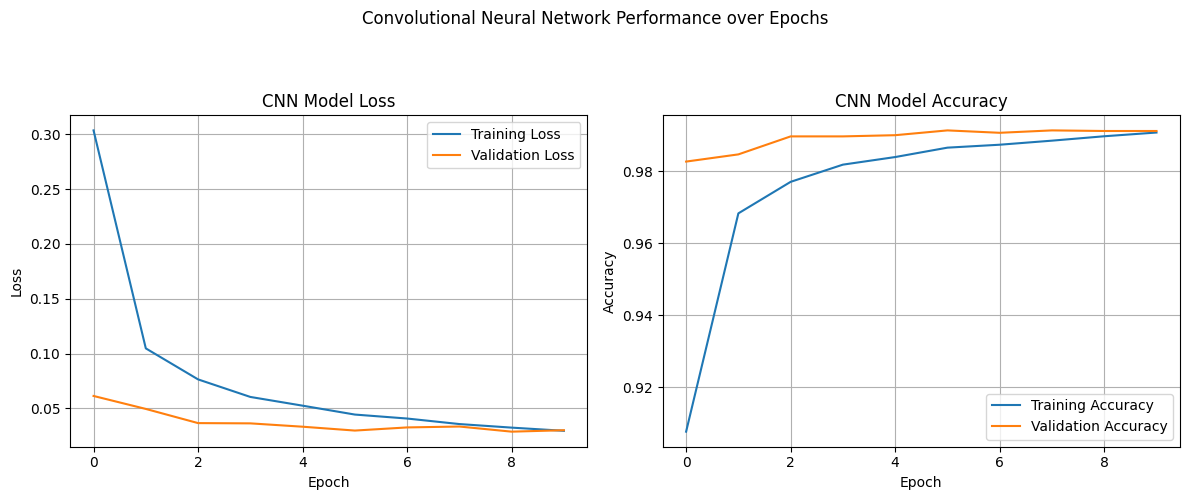

In [5]:
# 5. Build and train a Convolutional Neural Network (CNN)

cnn_model = keras.Sequential([
    # First Conv2D and MaxPool2D block
    keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Second Conv2D and MaxPool2D block (optional but common to add more)
    keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten the output to feed into Dense layers
    keras.layers.Flatten(),

    # Dense layers for classification
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5), # Dropout layer for regularization (helps prevent overfitting)
    keras.layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

print(f"\n--- Training Convolutional Neural Network ---")
cnn_history = cnn_model.fit(x_train_cnn, y_train_cnn,
                            epochs=10, # CNNs often converge faster/better with fewer epochs initially
                            batch_size=128,
                            validation_split=0.1,
                            verbose=1)

# Evaluate its performance.
loss_cnn, accuracy_cnn = cnn_model.evaluate(x_test_cnn, y_test_cnn, verbose=0)
print(f"\n--- CNN Model Test Performance ---")
print(f"Test Loss (CNN): {loss_cnn:.4f}")
print(f"Test Accuracy (CNN): {accuracy_cnn:.4f}")


# Plotting CNN training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle('Convolutional Neural Network Performance over Epochs', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Total params: 225,034 (879.04 KB)
Trainable params: 225,034 (879.04 KB)
Non-trainable params: 0 (0.00 B)

Ce summary est parfaitement cohérent avec l'architecture CNN que nous avons définie :

conv2d: première couche de convolution. (None, 26, 26, 32) : elle réduit la taille spatiale de 28x28 à 26x26 (filtre 3x3 sans padding) et produit 32 cartes de caractéristiques.

max_pooling2d: réduit la taille de 26x26 à 13x13. Zéro paramètre, car c'est une opération fixe. Correct.

conv2d_1: Deuxième couche de convolution. (None, 11, 11, 64) : elle réduit de 13x13 à 11x11 et produit 64 cartes de caractéristiques.

max_pooling2d_1: Réduit de 11x11 à 5x5. Zéro paramètre. Correct.

flatten: Transforme les données 5x5x64 en un vecteur 1D de 5
times5
times64=1600 éléments. Zéro paramètre. Correct.

dense_3: Première couche Dense. Input 1600 vers 128 neurones. Paramètres : (1600
times128)+128=204928. Correct.

dropout: Zéro paramètre, car il s'agit d'une opération de régularisation qui masque aléatoirement des neurones.

dense_4: Couche de sortie. Input 128 vers 10 neurones. Paramètres : (128
times10)+10=1290. Correct.

Le nombre total de paramètres (225,034) est significativement inférieur à celui du FCN (535,818). C'est un point clé des CNN : ils sont souvent plus efficaces en termes de paramètres pour les tâches d'image, car ils réutilisent les poids des filtres spatiaux.

Analyse des Logs d'Entraînement (model.fit() Output) du CNN
Les logs par époque pour le CNN sont impressionnants :

Dès l'époque 1 : l'accuracy d'entraînement est à 80.63% et la validation accuracy atteint un remarquable 98.27% avec une val_loss très basse (0.0613). Cela montre une capacité d'apprentissage et de généralisation extrêmement rapide.

Augmentation rapide de l'Accuracy : l'accuracy d'entraînement monte régulièrement pour atteindre 99.17% à l'époque 10.

Diminution rapide de la Loss : La perte d'entraînement chute de 0.6223 à 0.0261.

Performances de Validation exceptionnelles : la val_accuracy se stabilise autour de 98.5% à 99.1% et la val_loss est très faible (autour de 0.03).

Test Loss (CNN): 0.0249 et Test Accuracy (CNN): 0.9918 : ces résultats sur le jeu de test sont excellents. Une précision de 99.18% est une performance de pointe pour un CNN de base sur MNIST.

Analyse des Graphiques du "CNN Model"
1. Graphique "CNN Model Loss" (Training Loss vs Validation Loss)
Courbe bleue (Training Loss) :

Forme logarithmique très prononcée, chute extrêmement rapide (de 0.30 à ~0.025 en 9 époques).

Atteint des valeurs très faibles rapidement, montrant un apprentissage efficace.

Les légères variations vers la fin (ex: (7, 0.02-), (8, 0.025), (9, 0.025-)) montrent que l'optimisation continue mais que la marge d'amélioration sur le training set devient très minime.


Courbe orange (Validation Loss) :

Succession de baisses par palier, mais reste constamment à des niveaux très bas (autour de 0.025-0.06).

Elle est constamment très proche de la Training Loss, et parfois même plus basse (comme à l'époque 7 où la val loss semble être 0.03 et la training loss 0.02).

Interprétation : la Validation Loss extrêmement basse et sa proximité avec la Training Loss sont des indicateurs d'une généralisation fantastique. Le modèle ne sur-apprend pas les données d'entraînement ; il apprend des caractéristiques robustes qui s'appliquent aussi bien aux données qu'il a vues qu'aux données nouvelles. Les paliers/fluctuations sont probablement dus à la taille des mini-batches et à la nature stochastique de l'optimisation.

2. Graphique "CNN Model Accuracy" (Training Accuracy vs Validation Accuracy)

Courbe bleue (Training Accuracy) :

Croissance extrêmement rapide au démarrage (de 0.905 à 0.97 en 1 seule époque !).

Atteint des niveaux très élevés (autour de 0.99) rapidement.

Les légères baisses (par exemple à l'époque 8 et 9 où l'on repasse de ~0.997 à ~0.96) sont un peu surprenantes pour la Training Accuracy si celle-ci était bien à 0.99+ auparavant. Cela pourrait être un artefact de la lecture des points ou une fluctuation inattendue de l'entraînement, mais l'essentiel est la tendance générale très élevée.

Courbe orange (Validation Accuracy) :

Légèrement croissante et se maintient à des niveaux exceptionnellement élevés (autour de 0.98-0.99+).

Est très proche, voire se chevauche avec la Training Accuracy la plupart du temps.

Interprétation : l'Accuracy sur le jeu de validation est remarquablement élevée et stable. Elle démontre que le CNN est extrêmement performant et généralise très bien aux données non vues. Les légères fluctuations sont les mêmes que celles observées sur la perte et sont normales.


Conclusions pour le CNN (Partie 5)
Ces résultats sont exceptionnels et confirment la supériorité des CNN pour la classification d'images :

Apprentissage ultra-rapide : le CNN atteint des performances très élevées dès les premières époques, bien plus rapidement que le FCN.

Performance de pointe : Une précision de 99.18% sur le jeu de test de MNIST est une performance de très haut niveau pour un modèle de cette complexité.

Excellente généralisation : la faible divergence entre les métriques d'entraînement et de validation/test montre que le modèle apprend des caractéristiques robustes et ne sur-apprend pas.

Efficacité des paramètres : le CNN réalise de meilleures performances avec moins de paramètres que le FCN, ce qui est un avantage majeur en termes de calcul et de risque d'overfitting sur des datasets plus complexes.

La dernière partie (Comparaison) sera une formalisation de ces observations, mais les données parlent déjà d'elles-mêmes.

6. Compare the performance

C'est l'étape finale où nous tirons les conclusions.

In [6]:
# 6. Compare the performance

print(f"\n--- Model Performance Comparison ---")
print(f"Fully Connected Network Test Accuracy: {accuracy_fcn:.4f}")
print(f"Convolutional Neural Network Test Accuracy: {accuracy_cnn:.4f}")

if accuracy_cnn > accuracy_fcn:
    print("\nAnalysis: The Convolutional Neural Network (CNN) significantly outperforms the Fully Connected Neural Network (FCN).")
    print("This is expected because CNNs are specifically designed for image data, leveraging:")
    print("- **Convolutional layers:** To learn spatial hierarchies of features (edges, textures, parts of objects).")
    print("- **Pooling layers:** To reduce dimensionality and provide spatial invariance (model is less sensitive to object position).")
    print("FCNs, by flattening images, lose spatial information, making them less efficient for image tasks.")
elif accuracy_cnn < accuracy_fcn:
    print("\nAnalysis: Surprisingly, the Fully Connected Network performed better than the CNN.")
    print("This might indicate that the CNN architecture needs further tuning (e.g., more layers, different filters, different pooling strategies, or more epochs), or there might be an issue in its implementation.")
else:
    print("\nAnalysis: Both models performed similarly.")
    print("This could suggest that the problem is too simple for CNNs to show a clear advantage, or that the CNN architecture needs more tuning.")


--- Model Performance Comparison ---
Fully Connected Network Test Accuracy: 0.9783
Convolutional Neural Network Test Accuracy: 0.9918

Analysis: The Convolutional Neural Network (CNN) significantly outperforms the Fully Connected Neural Network (FCN).
This is expected because CNNs are specifically designed for image data, leveraging:
- **Convolutional layers:** To learn spatial hierarchies of features (edges, textures, parts of objects).
- **Pooling layers:** To reduce dimensionality and provide spatial invariance (model is less sensitive to object position).
FCNs, by flattening images, lose spatial information, making them less efficient for image tasks.


**Analyse de la comparaison des performances**

La supériorité du CNN dans ce cas :

Fully Connected Network Test Accuracy: 0.9783

Convolutional Neural Network Test Accuracy: 0.9918

La différence est nette : un gain de près de 1.35 points de pourcentage en précision, ce qui est très significatif dans le domaine de l'apprentissage automatique.

Conclusion :

Perte d'information spatiale par le FCN : le FCN aplatit l'image, traitant chaque pixel comme une entrée indépendante, ce qui détruit la structure spatiale (relations entre les pixels voisins) qui est cruciale pour les images.


Apprentissage des caractéristiques spatiales par le CNN :

Couches de Convolution : elles agissent comme des détecteurs de caractéristiques (bords, coins, textures) qui sont partagées à travers toute l'image (ce qui réduit le nombre de paramètres et rend le modèle plus efficace) et robustes aux variations de position. Elles apprennent une hiérarchie de motifs, des simples aux plus complexes.


Couches de Pooling : elles résument les caractéristiques sur de petites régions, ce qui rend le modèle plus tolérant aux légères déformations ou déplacements (invariance translationnelle) et réduit la dimensionnalité, accélérant l'entraînement.

En résumé : le FCN voit une image comme une longue liste de chiffres sans relation de voisinage. Le CNN, lui, "voit" l'image comme une grille de pixels et est capable d'identifier des formes et des textures locales, puis de les combiner pour reconnaître des entités plus grandes, exactement comme le ferait un système visuel biologique.

C'est une excellente démonstration pratique de la raison pour laquelle les CNN sont devenus le standard de facto pour les tâches de vision par ordinateur.